In [1]:
# Libraries
from sqlalchemy import create_engine, URL, text
import pandas as pd
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt

In [2]:
load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME")
)

engine = create_engine(url)

In [3]:
# GAMES
games_csv = pd.read_csv("../data/processed/games_clean.csv")

games_count = pd.read_sql(
    "SELECT COUNT(*) AS count FROM games;",
    engine
)

print("Games CSV:", len(games_csv))
print("Games PostgreSQL:", games_count["count"][0])

games_result = pd.read_sql("""
    SELECT *
    FROM games
    LIMIT 10;
""", engine)

display(games_result)

# STEAM
steam_csv = pd.read_csv("../data/processed/steam_clean.csv")

steam_count = pd.read_sql(
    "SELECT COUNT(*) AS count FROM steam;",
    engine
)

print("Steam CSV:", len(steam_csv))
print("Steam PostgreSQL:", steam_count["count"][0])

steam_result = pd.read_sql("""
    SELECT *
    FROM steam
    LIMIT 10;
""", engine)

display(steam_result)

# PROFILE
profile_csv = pd.read_csv("../data/processed/profile_clean.csv")

profile_count = pd.read_sql(
    "SELECT COUNT(*) AS count FROM profile;",
    engine
)

print("Profile CSV:", len(profile_csv))
print("Profile PostgreSQL:", profile_count["count"][0])

profile_result = pd.read_sql("""
    SELECT *
    FROM profile
    LIMIT 10;
""", engine)

display(profile_result)

Games CSV: 65109
Games PostgreSQL: 65109


,app_id,title,reviews_total,reviews_score_fancy,release_date,launch_price,tags,revenue_estimated,modified_tags,steam_page
0,730,Counter-Strike: Global Offensive,7382695,0.8800,2012-08-21,14.99,"FPS, Shooter, Multiplayer, Competitive, Action...",1.106666e+08,"FPS_, Shooter_, Multiplayer_, Competitive_, Ac...",https://store.steampowered.com/app/730
1,578080,PUBG: BATTLEGROUNDS,2201296,0.5700,2017-12-21,29.99,"Survival, Shooter, Battle Royale, Multiplayer,...",6.601687e+07,"Survival_, Shooter_, Battle Royale_, Multiplay...",https://store.steampowered.com/app/578080
2,570,Dota 2,2017009,0.8200,2013-07-09,29.99,"Free to Play, MOBA, Multiplayer, Strategy, eSp...",6.049010e+07,"Free to Play_, MOBA_, Multiplayer_, Strategy_,...",https://store.steampowered.com/app/570
3,271590,Grand Theft Auto V,1322782,0.8985,2015-04-13,29.99,"Open World, Action, Multiplayer, Crime, Automo...",3.967023e+07,"Open World_, Action_, Multiplayer_, Crime_, Au...",https://store.steampowered.com/app/271590
4,359550,Tom Clancy's Rainbow Six® Siege,978762,0.8600,2015-12-01,59.99,"FPS, PvP, eSports, Shooter, Multiplayer, Tacti...",5.871593e+07,"FPS_, PvP_, eSports_, Shooter_, Multiplayer_, ...",https://store.steampowered.com/app/359550
5,105600,Terraria,927752,0.9700,2011-05-16,9.99,"Open World Survival Craft, Sandbox, Survival, ...",9.268242e+06,"Open World Survival Craft_, Sandbox_, Survival...",https://store.steampowered.com/app/105600
6,4000,Garry's Mod,841853,0.9600,2006-11-29,9.99,"Sandbox, Multiplayer, Funny, Moddable, Buildin...",8.410111e+06,"Sandbox_, Multiplayer_, Funny_, Moddable_, Bui...",https://store.steampowered.com/app/4000
7,252490,Rust,775223,0.8700,2018-02-08,39.99,"Survival, Crafting, Multiplayer, Open World, O...",3.100117e+07,"Survival_, Crafting_, Multiplayer_, Open World...",https://store.steampowered.com/app/252490
8,292030,The Witcher® 3: Wild Hunt,662523,0.9600,2015-05-18,39.99,"Open World, RPG, Story Rich, Atmospheric, Matu...",2.649429e+07,"Open World_, RPG_, Story Rich_, Atmospheric_, ...",https://store.steampowered.com/app/292030
9,945360,Among Us,585788,0.9200,2018-11-16,4.99,"Multiplayer, Online Co Op, Social Deduction, S...",2.923082e+06,"Multiplayer_, Online Co Op_, Social Deduction_...",https://store.steampowered.com/app/945360


Steam CSV: 612265
Steam PostgreSQL: 612265


,month,avg_players,gain,gain_percent,peak_players,name,steam_appid
0,2025-09-01,7805.25,883.12,0.1276,13254,Counter-Strike,10
1,2025-08-01,6922.13,-449.35,-0.0610,12168,Counter-Strike,10
2,2025-07-01,7371.48,-833.50,-0.1016,13951,Counter-Strike,10
3,2025-06-01,8204.98,-847.53,-0.0936,15798,Counter-Strike,10
4,2025-05-01,9052.51,-471.31,-0.0495,15333,Counter-Strike,10
5,2025-04-01,9523.82,-849.53,-0.0819,17727,Counter-Strike,10
6,2025-03-01,10373.35,-1190.16,-0.1029,18180,Counter-Strike,10
7,2025-02-01,11563.50,-341.15,-0.0287,18934,Counter-Strike,10
8,2025-01-01,11904.66,413.55,0.0360,20626,Counter-Strike,10
9,2024-12-01,11491.11,1253.53,0.1224,19006,Counter-Strike,10


Profile CSV: 86590690
Profile PostgreSQL: 86590690


,hours_on_record,hours_last_2_weeks,appid,profile_code
0,0.466667,0.0,218620,1393209
1,7.916667,0.0,266840,1393209
2,163.816667,0.0,271590,1393209
3,9.350000,0.0,304930,1393209
4,81.233333,0.0,730,1393209
5,3.100000,0.0,346110,1393209
6,1.266667,0.0,287290,1393209
7,23.866667,0.0,322330,1393209
8,113.833333,0.0,381210,1393209
9,6.100000,0.0,359550,1393209


In [4]:
query = """SELECT COUNT(DISTINCT s.steam_appid) as matching_games FROM steam as s
INNER JOIN games as g
ON s.steam_appid = g.app_id"""

query1 = """SELECT COUNT(DISTINCT steam_appid) as total_games FROM steam"""

display(pd.read_sql(query, engine))

display(pd.read_sql(query1, engine))

,matching_games
0,5789


,total_games
0,6729


In [5]:
query = """SELECT COUNT(DISTINCT p.appid) AS matching_games FROM profile AS p
INNER JOIN games AS g
ON p.appid = g.app_id;
"""

query1 = """SELECT COUNT(DISTINCT appid) as total_games FROM profile"""

display(pd.read_sql(query, engine))

display(pd.read_sql(query1, engine))

,matching_games
0,36547


,total_games
0,52112


In [12]:
# Create 1 row = 1 game for steam.csv and profile.csv
query = """CREATE TABLE steam_summary AS
SELECT steam_appid, 
COUNT(month) as months_observed,
MIN(month) as first_month,
MAX(month) as last_month,
MIN(avg_players) as min_avg_players,
MAX(avg_players) as max_avg_players,
AVG(avg_players) as avg_players,
AVG(peak_players) as avg_peak_players
FROM steam
GROUP BY steam_appid
"""

# with engine.begin() as conn:
#     conn.execute(text(query))

steam_summary = pd.read_sql("SELECT * FROM steam_summary;", engine)

steam_summary.shape

(6729, 8)

In [13]:
query = """CREATE TABLE profile_summary AS
SELECT appid, 
COUNT(DISTINCT profile_code) as players,
AVG(hours_on_record) as avg_engagement,
SUM(hours_on_record) as total_engagement,
MAX(hours_on_record) as max_engagement
FROM profile
GROUP BY appid
"""

# with engine.begin() as conn:
#     conn.execute(text(query))

profile_summary = pd.read_sql("SELECT * FROM profile_summary;", engine)

profile_summary.shape

(52112, 5)

In [14]:
# Join tables
query = """CREATE TABLE game_steam_summary AS
SELECT g.app_id, g.title, g.release_date, g.launch_price, g.reviews_total, g.reviews_score_fancy,
s.months_observed, s.first_month, s.last_month, s.min_avg_players, s.max_avg_players, s.avg_players, s.avg_peak_players
FROM games g
INNER JOIN steam_summary s
ON g.app_id = s.steam_appid;
"""

# with engine.begin() as conn:
#     conn.execute(text(query))

game_steam_summary = pd.read_sql("SELECT * FROM game_steam_summary;", engine)

game_steam_summary

,app_id,title,release_date,launch_price,reviews_total,reviews_score_fancy,months_observed,first_month,last_month,min_avg_players,max_avg_players,avg_players,avg_peak_players
0,730,Counter-Strike: Global Offensive,2012-08-21,14.99,7382695,0.8800,159,2012-07-01,2025-09-01,932.57,1117517.40,471708.649623,806494.025157
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,29.99,2201296,0.5700,103,2017-03-01,2025-09-01,17551.14,1584886.77,348401.458252,803437.262136
2,271590,Grand Theft Auto V,2015-04-13,29.99,1322782,0.8985,126,2015-04-01,2025-09-01,25230.19,192714.01,77629.456905,144535.634921
3,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,59.99,978762,0.8600,118,2015-12-01,2025-09-01,6125.46,119877.88,52297.545254,94892.059322
4,105600,Terraria,2011-05-16,9.99,927752,0.9700,159,2012-07-01,2025-09-01,3191.02,129808.62,23154.646289,42969.352201
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5784,799570,Angles,2018-03-07,9.99,0,0.0000,2,2018-03-01,2018-04-01,0.01,0.06,0.035000,2.000000
5785,758440,Last Rose,2019-08-30,9.99,0,0.0000,1,2019-09-01,2019-09-01,0.21,0.21,0.210000,2.000000
5786,664590,Airi's World,2017-07-13,9.99,0,0.0000,7,2017-07-01,2019-08-01,0.01,0.23,0.054286,1.285714
5787,597640,"Buccaneers, Bounty & Boom!",2017-03-01,11.99,0,0.0000,4,2017-03-01,2019-05-01,0.01,0.09,0.042500,1.250000


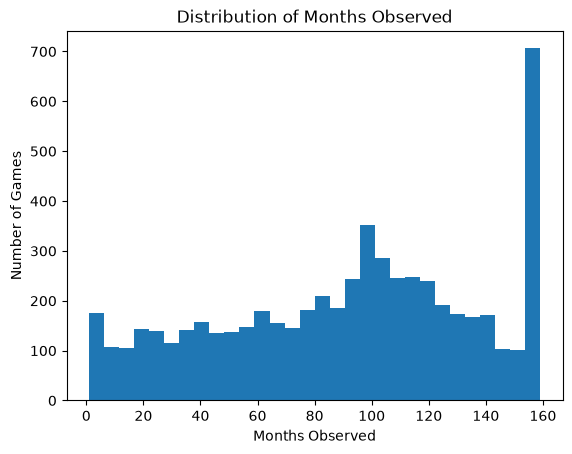

In [15]:
plt.hist(game_steam_summary["months_observed"], bins=30)

plt.xlabel("Months Observed")
plt.ylabel("Number of Games")
plt.title("Distribution of Months Observed")

plt.show()

# Can only include games with  > 12 or > 24 months as won't change much of the data

In [ ]:
history_counts = pd.read_sql("""
SELECT
    COUNT(*) AS total_games,
    COUNT(*) FILTER (WHERE months_observed >= 12) AS games_12_months,
    COUNT(*) FILTER (WHERE months_observed >= 24) AS games_24_months,
    COUNT(*) FILTER (WHERE months_observed >= 36) AS games_36_months
FROM game_steam_summary;
""", engine)

history_counts

# Since 24 months drop off is small, use 24 months

,total_games,games_12_months,games_24_months,games_36_months
0,5789,5507,5230,4913
